[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brilliantbeaver/alexpose/blob/main/experiments/sjepa/gavd4-vicreg/03_neurologic_keypoint_masking.ipynb)

# 03. Neurologically relevant keypoint-only masking

Reproduce the de-duplicated BlazePose target set from the mandated MS–PD mapping and make the no-motion-aware constraint executable.

**Research use only.** This tutorial does not diagnose a person or validate a clinical device.

**Run it:** locally, use `uv sync` then `uv run jupyter lab` from this folder. In Colab, use the badge and run the setup cell. Restart the kernel after changing `experiments/sjepa/gavd4-vicreg/.env`.


In [8]:
from pathlib import Path
import os
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/brilliantbeaver/alexpose.git"

if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "numpy", "pandas", "scipy", "scikit-learn", "matplotlib",
        "seaborn", "torch", "tqdm", "python-dotenv", "yt-dlp[default]",
        "opencv-python-headless", "mediapipe<1", "joblib", "pyarrow",
    ])
    clone_dir = Path("/content/alexpose")
    if not (clone_dir / ".git").exists():
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)])
    os.chdir(clone_dir)


def find_project_root(start=None):
    env_root = os.getenv("ALEXPOSE_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
        print(f"Ignoring invalid ALEXPOSE_ROOT: {candidate}")
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TUTORIAL_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd4-vicreg"

try:
    from dotenv import load_dotenv
    load_dotenv(TUTORIAL_DIR / ".env", override=False)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except Exception:
    pass

MODE = os.getenv("GAVD3_MODE", "smoke").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAVD3_MODE must be smoke or real")
if MODE == "smoke":
    print(
        "SMOKE MODE: hand-authored motions test code paths only. "
        "They have no pathophysiological or clinical validity."
    )

PREFERRED_ROOT = Path(
    os.getenv(
        "GAVD4_ROOT",
        str(PROJECT_ROOT / "data"),
    )
).expanduser()

requested_data = os.getenv("GAVD4_DATA_DIR") or os.getenv("GAVD_DATA_GAVD_DIR")
if requested_data and Path(requested_data).expanduser().exists():
    DATA_GAVD_DIR = Path(requested_data).expanduser()
elif requested_data:
    print(f"Ignoring missing GAVD CSV path: {Path(requested_data).expanduser()}")
    if (PREFERRED_ROOT / "data-gavd").exists():
        DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
    else:
        DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"
elif (PREFERRED_ROOT / "data-gavd").exists():
    DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
else:
    DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"

requested_youtube = os.getenv("GAVD4_YOUTUBE_DIR") or os.getenv("GAVD_YOUTUBE_DIR")
if requested_youtube:
    YOUTUBE_DIR = Path(requested_youtube).expanduser()
elif PREFERRED_ROOT.exists():
    YOUTUBE_DIR = PREFERRED_ROOT / "youtube"
else:
    YOUTUBE_DIR = PROJECT_ROOT / "data" / "youtube"

CACHE_DIR = Path(
    os.getenv("GAVD3_CACHE_DIR", TUTORIAL_DIR / "cache")
).expanduser()
ARTIFACT_ROOT = Path(
    os.getenv("GAVD3_ARTIFACT_DIR", CACHE_DIR / "artifacts")
).expanduser()
ARTIFACT_DIR = ARTIFACT_ROOT / MODE
POSE_DIR = ARTIFACT_DIR / "poses"

for folder in [CACHE_DIR, ARTIFACT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR / "xdg-cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
from IPython.display import SVG, display


def show_tutorial_svg(filename):
    '''Render a repository SVG reliably in local Jupyter and Colab.'''
    path = TUTORIAL_DIR / "images" / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Missing tutorial figure {path}. Clone the full alexpose repository."
        )
    display(SVG(filename=str(path)))

print(f"mode: {MODE}")
print(f"project: {PROJECT_ROOT}")
print(f"GAVD CSVs: {DATA_GAVD_DIR}")
print(f"YouTube cache: {YOUTUBE_DIR}")
print(f"artifacts: {ARTIFACT_DIR}")


mode: real
project: /Users/theodoremui/dev/alexpose
GAVD CSVs: /Users/theodoremui/dev/alexpose/data/gavd
YouTube cache: /Users/theodoremui/dev/alexpose/data/youtube
artifacts: /Users/theodoremui/dev/alexpose/experiments/sjepa/gavd4-vicreg/cache/artifacts/real


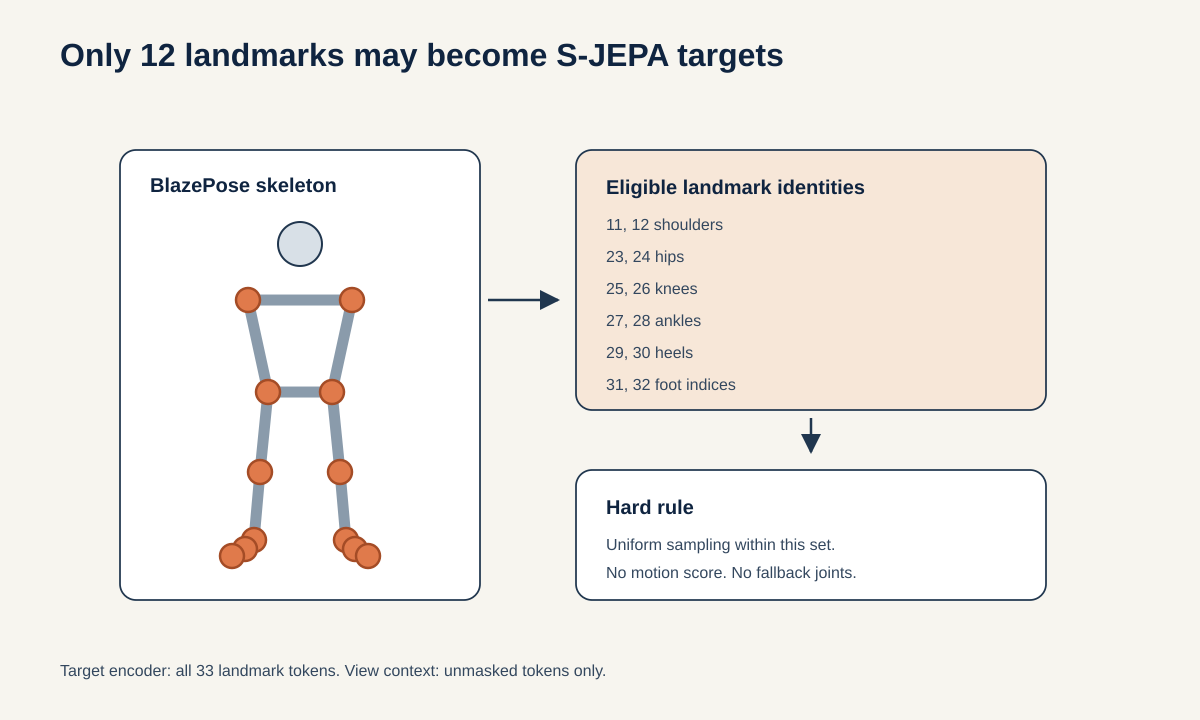

In [9]:
show_tutorial_svg("03_neurologic_mask.svg")


In [10]:
BLAZEPOSE_33 = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER",
    "RIGHT_EYE_INNER", "RIGHT_EYE", "RIGHT_EYE_OUTER", "LEFT_EAR",
    "RIGHT_EAR", "MOUTH_LEFT", "MOUTH_RIGHT", "LEFT_SHOULDER",
    "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST",
    "RIGHT_WRIST", "LEFT_PINKY", "RIGHT_PINKY", "LEFT_INDEX",
    "RIGHT_INDEX", "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP",
    "RIGHT_HIP", "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE",
    "RIGHT_ANKLE", "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX",
    "RIGHT_FOOT_INDEX",
]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
MASK_KEYPOINT_NAMES = [
    "LEFT_SHOULDER", "RIGHT_SHOULDER", "LEFT_HIP", "RIGHT_HIP",
    "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE", "RIGHT_ANKLE",
    "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX", "RIGHT_FOOT_INDEX",
]
assert MASK_KEYPOINTS == sorted(set(MASK_KEYPOINTS))
assert [BLAZEPOSE_33[i] for i in MASK_KEYPOINTS] == MASK_KEYPOINT_NAMES


MAPPING_RELATIVE_PATH = Path(
    "experiments/multiple-sclerosis/mapping-data/ms-pd-mapping.md"
)
MAPPING_PATH = PROJECT_ROOT / MAPPING_RELATIVE_PATH
if not MAPPING_PATH.is_file():
    raise FileNotFoundError(f"Required mapping file is missing: {MAPPING_PATH}")

MASK_FEATURES_BY_INDEX = {
    11: ("shoulder_symmetry_index", "trunk_lean_angle"),
    12: ("shoulder_symmetry_index", "trunk_lean_angle"),
    23: ("walking_speed_ms", "left/right_knee_range", "hip_asymmetry", "trunk_lean_angle"),
    24: ("walking_speed_ms", "left/right_knee_range", "hip_asymmetry", "trunk_lean_angle"),
    25: ("left/right_knee_range", "left/right_ankle_range"),
    26: ("left/right_knee_range", "left/right_ankle_range"),
    27: ("left/right_knee_range", "left/right_ankle_range", "step_width_m"),
    28: ("left/right_knee_range", "left/right_ankle_range", "step_width_m"),
    29: ("stride_length_m", "double_support_percentage", "stride_time_cv", "left/right_ankle_range"),
    30: ("stride_length_m", "double_support_percentage", "stride_time_cv", "left/right_ankle_range"),
    31: ("stride_length_m", "double_support_percentage", "stride_time_cv", "left/right_ankle_range"),
    32: ("stride_length_m", "double_support_percentage", "stride_time_cv", "left/right_ankle_range"),
}
assert set(MASK_FEATURES_BY_INDEX) == set(MASK_KEYPOINTS)
mapping_text = MAPPING_PATH.read_text(encoding="utf-8")
assert all(f"({index})" in mapping_text for index in [11, 12, 23, 24, 25, 26, 27, 28, 31, 32])
assert "29–32" in mapping_text and "29,30" in mapping_text
print("mapping source:", MAPPING_RELATIVE_PATH)


mapping source: experiments/multiple-sclerosis/mapping-data/ms-pd-mapping.md


## Required de-duplicated table

The only source for this whitelist is `experiments/multiple-sclerosis/mapping-data/ms-pd-mapping.md`. Repeated landmarks and inclusive ranges such as “Feet (29–32)” are expanded, de-duplicated by BlazePose index, and sorted numerically. The source maps MS/PD features; it does not claim that these landmarks diagnose any of the five GAVD groups.

|BLAZEPOSE_33 index|Keypoint name|Features involved|
|---:|---|---|
|11|LEFT_SHOULDER|`shoulder_symmetry_index`, `trunk_lean_angle`|
|12|RIGHT_SHOULDER|`shoulder_symmetry_index`, `trunk_lean_angle`|
|23|LEFT_HIP|`walking_speed_ms`, `left/right_knee_range`, `hip_asymmetry`, `trunk_lean_angle`|
|24|RIGHT_HIP|`walking_speed_ms`, `left/right_knee_range`, `hip_asymmetry`, `trunk_lean_angle`|
|25|LEFT_KNEE|`left/right_knee_range`, `left/right_ankle_range`|
|26|RIGHT_KNEE|`left/right_knee_range`, `left/right_ankle_range`|
|27|LEFT_ANKLE|`left/right_knee_range`, `left/right_ankle_range`, `step_width_m`|
|28|RIGHT_ANKLE|`left/right_knee_range`, `left/right_ankle_range`, `step_width_m`|
|29|LEFT_HEEL|`stride_length_m`, `double_support_percentage`, `stride_time_cv`, `left/right_ankle_range`|
|30|RIGHT_HEEL|`stride_length_m`, `double_support_percentage`, `stride_time_cv`, `left/right_ankle_range`|
|31|LEFT_FOOT_INDEX|`stride_length_m`, `double_support_percentage`, `stride_time_cv`, `left/right_ankle_range`|
|32|RIGHT_FOOT_INDEX|`stride_length_m`, `double_support_percentage`, `stride_time_cv`, `left/right_ankle_range`|


## The restriction is about targets, not context

S-JEPA needs the global skeleton context. The target encoder therefore sees all 33 landmarks. The view encoder also sees every unselected token. Only the 12 listed landmarks are eligible to be removed and predicted.

For temporal segment index s and allowed landmark set K:

\[
\mathcal{E} = \{(s,j): s \in [0,S), j \in K\}
\]

The sampler draws uniformly without replacement from this eligible set. It never reads coordinate magnitude, velocity, acceleration, topology weights, or a motion score.


In [11]:
def uniform_neurologic_mask(valid_patch, mask_fraction=0.60, seed=None):
    """Sample eligible joint-time tokens uniformly, without motion scores.

    valid_patch has shape [B, S, V]. True means that a patch can be a target.
    The returned mask has the same shape. True means hidden from the view encoder.
    """
    valid_patch = np.asarray(valid_patch, dtype=bool)
    if valid_patch.ndim != 3 or valid_patch.shape[2] != 33:
        raise ValueError(f"Expected [B, S, 33], received {valid_patch.shape}")
    if not 0.0 < mask_fraction < 1.0:
        raise ValueError("mask_fraction must be between 0 and 1")
    rng = np.random.default_rng(seed)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    counts = eligible.reshape(len(eligible), -1).sum(axis=1)
    if np.any(counts < 2):
        raise ValueError("Each sample needs at least two valid eligible tokens")
    n_mask = max(1, int(np.floor(counts.min() * mask_fraction)))
    n_mask = min(n_mask, int(counts.min()) - 1)
    mask = np.zeros_like(eligible)
    for batch_index in range(len(mask)):
        candidates = np.flatnonzero(eligible[batch_index].reshape(-1))
        chosen = rng.choice(candidates, size=n_mask, replace=False)
        mask[batch_index].reshape(-1)[chosen] = True
    forbidden = sorted(set(range(33)).difference(MASK_KEYPOINTS))
    assert not mask[:, :, forbidden].any()
    assert mask.reshape(len(mask), -1).any(axis=1).all()
    assert (~mask).reshape(len(mask), -1).any(axis=1).all()
    return mask


def mask_audit(mask, valid_patch):
    mask = np.asarray(mask, dtype=bool)
    valid_patch = np.asarray(valid_patch, dtype=bool)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    masked_counts = mask.reshape(len(mask), -1).sum(axis=1)
    eligible_counts = eligible.reshape(len(mask), -1).sum(axis=1)
    per_sample_ratio = masked_counts / eligible_counts
    touched = np.flatnonzero(mask.any(axis=(0, 1))).tolist()
    return {
        "masked_keypoints": touched,
        "masked_names": [BLAZEPOSE_33[i] for i in touched],
        "global_fraction": float(mask.mean()),
        "eligible_mask_fraction_min": float(per_sample_ratio.min()),
        "eligible_mask_fraction_mean": float(per_sample_ratio.mean()),
        "eligible_mask_fraction_max": float(per_sample_ratio.max()),
        "forbidden_count": int(mask[:, :, sorted(set(range(33)) - set(MASK_KEYPOINTS))].sum()),
    }


## Create one mask

A valid-patch matrix can exclude natural tracking failures from the target pool. This is quality control, not motion-aware selection.


In [12]:
batch_size, segments, joints = 4, 16, 33
valid_patch = np.ones((batch_size, segments, joints), dtype=bool)
valid_patch[0, 3:5, 27] = False
mask = uniform_neurologic_mask(
    valid_patch,
    mask_fraction=0.60,
    seed=42,
)
audit = mask_audit(mask, valid_patch)
audit


{'masked_keypoints': [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32],
 'masked_names': ['LEFT_SHOULDER',
  'RIGHT_SHOULDER',
  'LEFT_HIP',
  'RIGHT_HIP',
  'LEFT_KNEE',
  'RIGHT_KNEE',
  'LEFT_ANKLE',
  'RIGHT_ANKLE',
  'LEFT_HEEL',
  'RIGHT_HEEL',
  'LEFT_FOOT_INDEX',
  'RIGHT_FOOT_INDEX'],
 'global_fraction': 0.2159090909090909,
 'eligible_mask_fraction_min': 0.59375,
 'eligible_mask_fraction_mean': 0.5953125,
 'eligible_mask_fraction_max': 0.6,
 'forbidden_count': 0}

The valid-eligible fraction is larger than the global fraction because only 12 of 33 joints are eligible. Matching the paper's 90 percent global ratio would require masking forbidden joints, so this adaptation does not do it.


In [13]:
allowed_capacity = len(MASK_KEYPOINTS) / 33
print(f"maximum possible global fraction: {allowed_capacity:.3f}")
print(f"minimum valid-eligible fraction: {audit['eligible_mask_fraction_min']:.3f}")
print(f"mean valid-eligible fraction: {audit['eligible_mask_fraction_mean']:.3f}")
print(f"maximum valid-eligible fraction: {audit['eligible_mask_fraction_max']:.3f}")
print(f"realized global fraction: {audit['global_fraction']:.3f}")


maximum possible global fraction: 0.364
minimum valid-eligible fraction: 0.594
mean valid-eligible fraction: 0.595
maximum valid-eligible fraction: 0.600
realized global fraction: 0.216


## Adversarial mask tests

These checks are intentionally redundant. A future refactor should fail loudly if it masks a wrist, face landmark, or any other token outside the 12-landmark whitelist.


In [14]:
forbidden = sorted(set(range(33)) - set(MASK_KEYPOINTS))
assert mask.shape == (batch_size, segments, 33)
assert not mask[:, :, forbidden].any()
assert mask.reshape(batch_size, -1).any(axis=1).all()
assert (~mask).reshape(batch_size, -1).any(axis=1).all()
assert set(np.where(mask.any(axis=(0, 1)))[0]).issubset(MASK_KEYPOINTS)

same_seed = uniform_neurologic_mask(valid_patch, 0.60, seed=42)
different_seed = uniform_neurologic_mask(valid_patch, 0.60, seed=43)
assert np.array_equal(mask, same_seed)
assert not np.array_equal(mask, different_seed)

counts = mask.reshape(batch_size, -1).sum(axis=1)
assert np.all(counts == counts[0])
assert audit["forbidden_count"] == 0
print("All mask invariants passed.")


All mask invariants passed.


## Policies that are explicitly absent

- No per-joint motion magnitude.
- No temporal difference score.
- No softmax over motion intensity.
- No Gumbel ranking from motion probabilities.
- No topology group expansion.
- No second random draw over temporal blocks.
- No fallback to another joint when an eligible target is unavailable.

The sampler always produces at least one target and leaves at least one visible token per sample. It applies mask_fraction exactly once.


## Why stochastic targets are better than permanently hiding all 12 joints

Each neurologically relevant token is sometimes visible and sometimes predicted. This lets its patch embedding learn directly while still making it a frequent latent target. Permanently hiding all 12 joints would deprive their view-side inputs of direct training.

Notebook 04 uses this exact mask function in normal-only Stage 0 and every progressive continuation stage.
